In [1]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

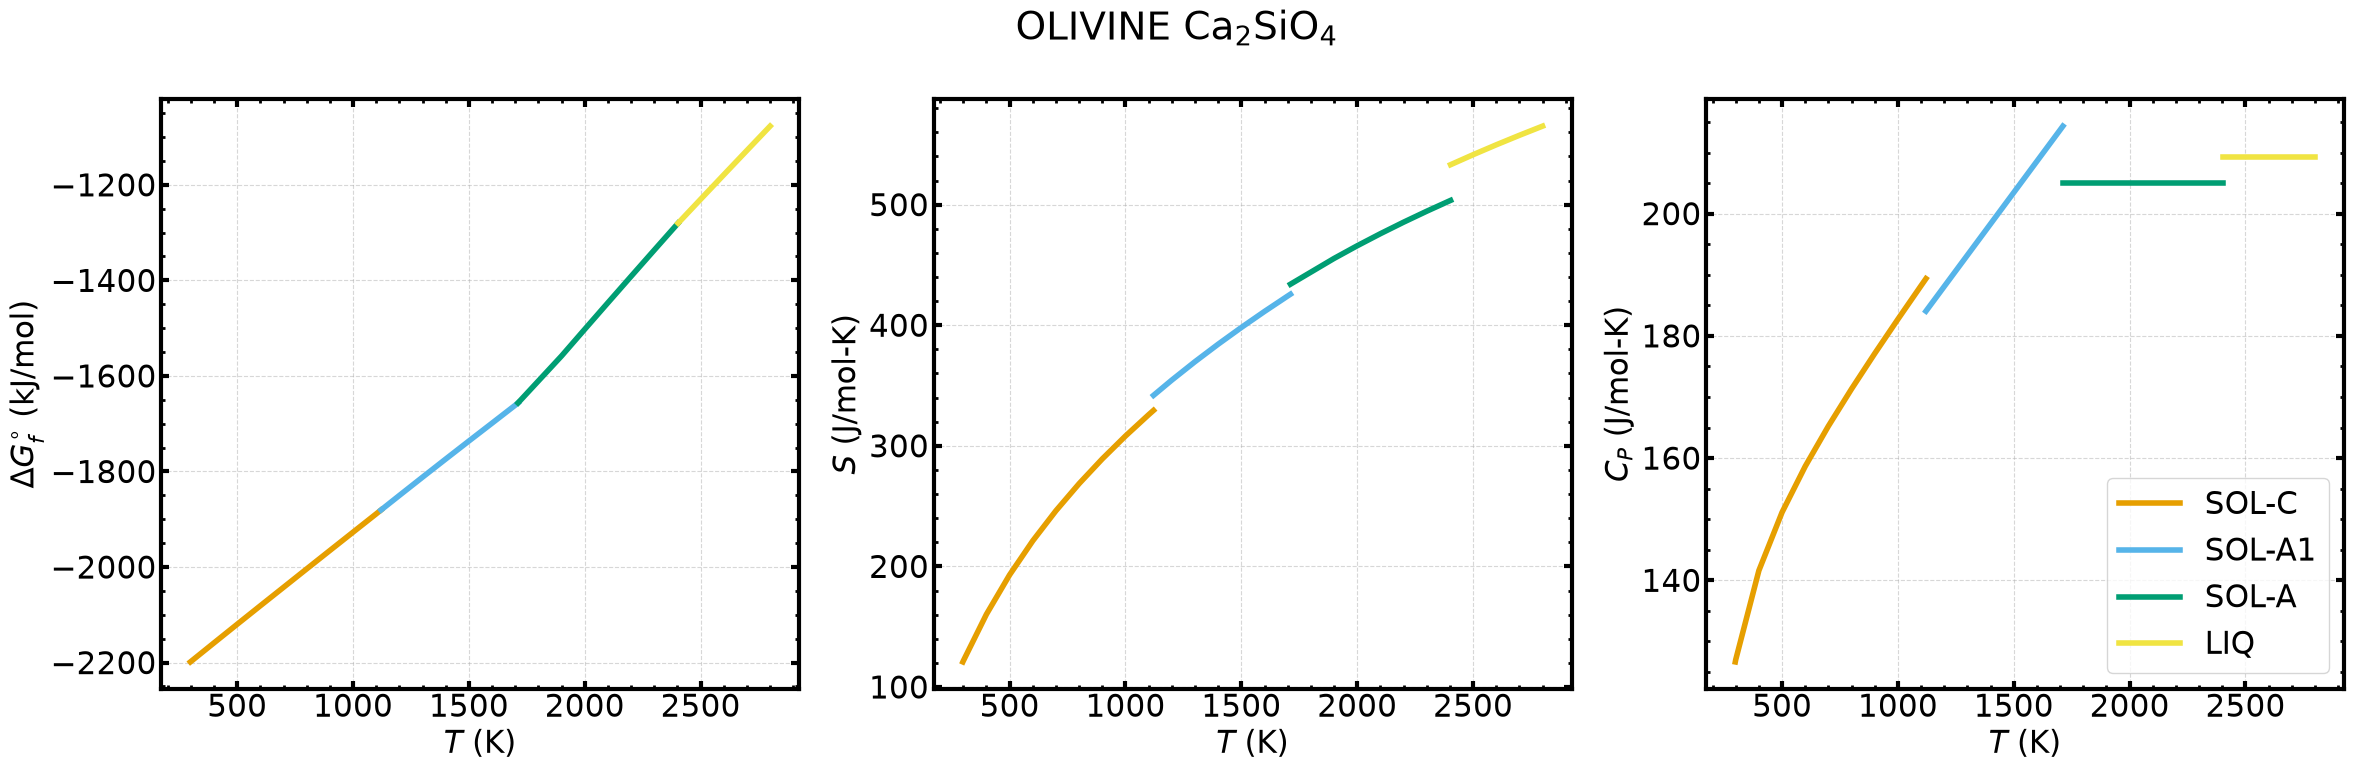

In [2]:
# Set Okabe-Ito colorblind-friendly palette
cb_palette = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
mpl.rcParams['axes.prop_cycle'] = cycler(color=cb_palette)

lookup_formulas = ["Ca2SiO4"]
str_formulas = ["Ca$_2$SiO$_4$"]
output_dir = "barin_json_data"

for lookup_formula, str_formula in zip(lookup_formulas, str_formulas):
    
    # Reconstruct the exact safe filename used during extraction
    safe_filename = "".join(c for c in lookup_formula if c.isalnum() or c in "_-[]*") + ".json"
    file_path = os.path.join(output_dir, safe_filename)

    # Safely check if we actually extracted this file to avoid crashes
    if not os.path.exists(file_path):
        print(f"File not found for {lookup_formula}, skipping...")
        continue

    # Load the JSON data back into a Python dictionary
    with open(file_path, 'r') as f:
        data = json.load(f)

    # Extract the name and the nested phases dictionary
    name = data["name"]
    phases = data["phases"]
    
    plt.rcParams.update({'font.size': 22})
    
    # 1 row, 3 columns with a wider figure size
    figsize = (24, 8)
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    fig.suptitle(f"{name} {str_formula}", fontsize=28)

    # Iterate through the dictionary keys and values
    for phase_name, phase_data in phases.items():
        
        # Pull the Temperature array to use as the X-axis
        T = phase_data["T"]
        
        # # Plot G
        # axs[0].plot(T, phase_data["G"], label=phase_name, linewidth=4)
        # axs[0].set_ylabel("$G$ (kJ/mol)")
        # print(phase_data["G"])
        
        # Plot delta_Gf
        axs[0].plot(T, phase_data["delta_Gf"], label=phase_name, linewidth=4)
        axs[0].set_ylabel("$\Delta G^{\circ}_f$ (kJ/mol)")
        # print(phase_data["delta_Gf"])

        # Plot S 
        axs[1].plot(T, phase_data["S"], label=phase_name, linewidth=4)
        axs[1].set_ylabel("$S$ (J/mol-K)")
        # print(phase_data["S"])
        
        # Plot Cp 
        axs[2].plot(T, phase_data["Cp"], label=phase_name, linewidth=4)
        axs[2].set_ylabel("$C_P$ (J/mol-K)")
        # print(phase_data["Cp"])
    
    for i, ax in enumerate(axs):
        # Set the thickness of the spines
        tickwidth = 3
        ax.spines['bottom'].set_linewidth(tickwidth)
        ax.spines['top'].set_linewidth(tickwidth)
        ax.spines['left'].set_linewidth(tickwidth)
        ax.spines['right'].set_linewidth(tickwidth)

        # Enable minor ticks
        ax.minorticks_on()
        
        # Configure major and minor ticks to point inwards on all sides
        ax.tick_params(which='major', width=tickwidth, length=2*tickwidth, direction='in', top=True, bottom=True, left=True, right=True)
        ax.tick_params(which='minor', width=tickwidth/1.5, length=tickwidth, direction='in', top=True, bottom=True, left=True,  right=True)

        ax.set_xlabel("$T$ (K)")
        if i == 2:
            ax.legend()
        ax.grid(True, which='major', linestyle='--', alpha=0.5)

    fig.tight_layout()
    plt.savefig("thermo_data_ex.svg", format="svg", bbox_inches='tight')
    plt.show()
    print(" \n \n \n ")